In [36]:
import pandas as pd 
import matplotlib.pyplot as plt

final_dataset = pd.read_csv('../dataset/final_dataset_diff_f_L10.csv')
final_dataset

,gameId,GAME_DATE,HOME_WON,H_teamId,A_teamId,ELO,ELO_PROB,NB_WIN_L10,PCT_3PT_L10,PCT_LANCER_FRANC_L10,...,estimatedNetRating_L10,estimatedOffensiveRating_L10,estimatedPace_L10,estimatedTeamTurnoverPercentage_L10,netRating_L10,offensiveRating_L10,pacePer40_L10,pace_L10,trueShootingPercentage_L10,turnoverRatio_L10
0,21300018,2013-10-31,1,1610612741,1610612752,-65.524500,0.098904,-0.1,0.0380,-0.0990,...,-24.10,-1.40,4.060,-4.4950,-18.50,1.20,3.750,4.500,-0.0630,-4.00
1,21300019,2013-10-31,1,1610612746,1610612744,0.516500,0.281499,-0.1,-0.1750,-0.2180,...,-36.80,-16.20,-2.460,1.7360,-40.80,-13.90,-5.000,-6.000,-0.0970,2.00
2,21300022,2013-11-01,0,1610612764,1610612755,-16.701200,0.235263,-0.1,0.0190,-0.0830,...,-13.70,-7.20,-3.840,-0.2060,-14.10,-7.70,-2.910,-3.500,-0.0750,-0.30
3,21300026,2013-11-01,1,1610612763,1610612765,199.627700,0.697491,-0.1,0.1580,-0.2550,...,-23.20,-21.90,0.520,-5.4470,-18.60,-16.40,-2.500,-3.000,-0.1390,-4.70
4,21300028,2013-11-01,1,1610612751,1610612748,-145.293300,-0.129631,-0.1,-0.1000,0.0280,...,-9.20,-11.80,-3.280,-4.0535,-8.40,-7.40,-5.830,-7.000,-0.1105,-3.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6616,22301220,2023-12-08,0,1610612748,1610612739,50.721890,0.408503,-0.2,0.0477,0.0354,...,0.67,6.80,-1.244,-3.6733,2.12,8.93,-1.897,-2.276,0.0210,-3.49
6617,22301224,2023-12-08,0,1610612743,1610612745,154.930567,0.625354,0.1,0.0319,-0.0623,...,-3.73,3.61,0.338,-1.3236,-1.55,3.75,1.043,1.250,-0.0025,-1.36
6618,22301225,2023-12-08,0,1610612762,1610612746,-147.160540,-0.134911,-0.4,-0.0211,0.0300,...,-18.24,-8.34,0.227,5.8950,-17.17,-7.28,-0.200,-0.241,-0.0213,6.25
6619,22301226,2023-12-08,0,1610612757,1610612742,-131.401620,-0.090136,-0.1,0.0281,0.0784,...,-6.61,-9.34,-1.915,5.2200,-6.22,-8.72,-2.117,-2.541,-0.0192,5.50


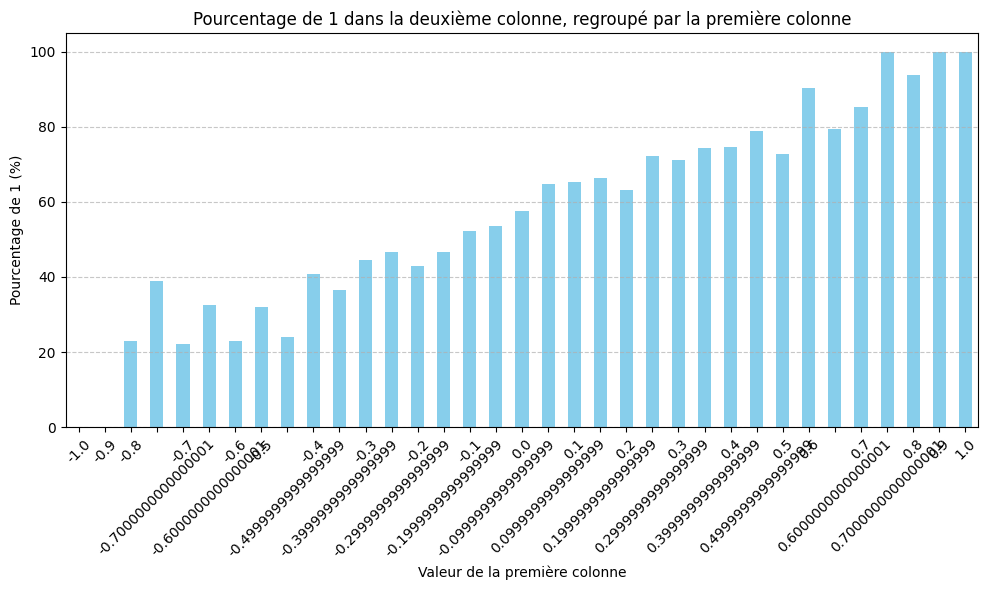

In [37]:
grouped = final_dataset.groupby('NB_WIN_L10')['HOME_WON'].apply(lambda x: (x.sum() / len(x)) * 100)
final_dataset

plt.figure(figsize=(10, 6))
grouped.plot(kind='bar', color='skyblue')
plt.title('Pourcentage de 1 dans la deuxième colonne, regroupé par la première colonne')
plt.xlabel('Valeur de la première colonne')
plt.ylabel('Pourcentage de 1 (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1297

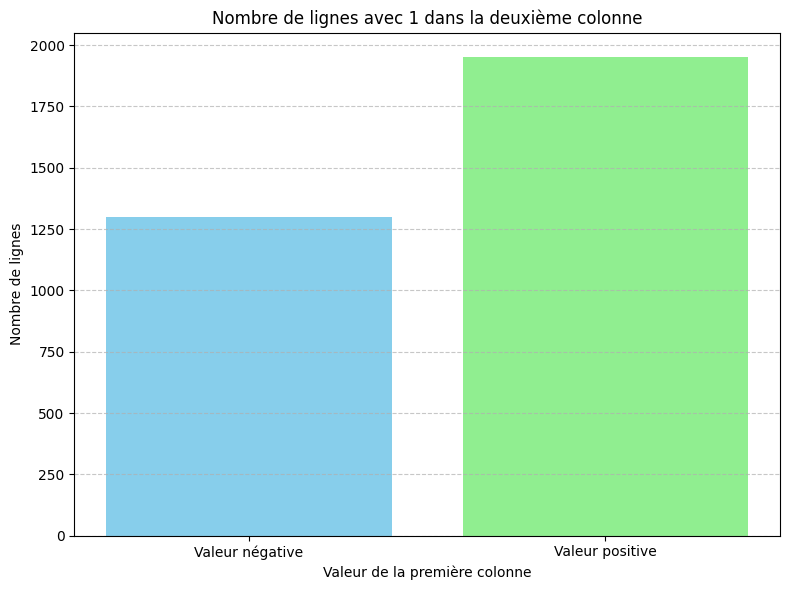

In [38]:
# Filtrer les lignes avec une valeur négative dans la première colonne et compter les 1 dans la deuxième colonne
neg_count = final_dataset[final_dataset['NB_WIN_L10'] < 0]
neg_count = len(neg_count[neg_count['HOME_WON'] == 1])

# Filtrer les lignes avec une valeur positive dans la première colonne et compter les 1 dans la deuxième colonne
pos_count = final_dataset[final_dataset['NB_WIN_L10'] > 0]
pos_count = len(pos_count[pos_count['HOME_WON'] == 1])

# Créer un graphique à barres
plt.figure(figsize=(8, 6))
plt.bar(['Valeur négative', 'Valeur positive'], [neg_count, pos_count], color=['skyblue', 'lightgreen'])
plt.title('Nombre de lignes avec 1 dans la deuxième colonne')
plt.ylabel('Nombre de lignes')
plt.xlabel('Valeur de la première colonne')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
neg_count

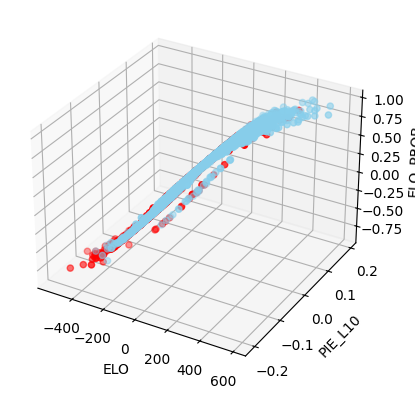

In [39]:
from mpl_toolkits.mplot3d import Axes3D


new_plot_df_won = final_dataset[final_dataset['HOME_WON'] == 1]
new_plot_df_loss = final_dataset[final_dataset['HOME_WON'] == 0]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Tracer le nuage de points en 3D
ax.scatter(new_plot_df_won['ELO'], new_plot_df_won['PIE_L10'], new_plot_df_won['ELO_PROB'], c='skyblue')
ax.scatter(new_plot_df_loss['ELO'], new_plot_df_loss['PIE_L10'], new_plot_df_loss ['ELO_PROB'], c='red')



# Ajouter des labels
ax.set_xlabel('ELO')
ax.set_ylabel('PIE_L10')
ax.set_zlabel('ELO_PROB')

# Afficher le nuage de points
plt.show()

In [40]:
import plotly.graph_objs as go
# Créer une trace de nuage de points
trace = go.Scatter3d(
    x=new_plot_df_won['ELO'],
    y=new_plot_df_won['ELO_PROB'],
    z=new_plot_df_won['PIE_L10'],
    mode='markers',
    marker=dict(
        size=1,
        color='blue',  # Choisir une couleur (Rouge dans cet exemple)
        opacity=0.8
    ),
    text=new_plot_df_won['GAME_DATE']
)

trace2 = go.Scatter3d(
    x=new_plot_df_loss['ELO'],
    y=new_plot_df_loss['ELO_PROB'],
    z=new_plot_df_loss['PIE_L10'],
    mode='markers',
    marker=dict(
        size=1,
        color='red',  # Choisir une couleur (Rouge dans cet exemple)
        opacity=0.8
    ),
    text=new_plot_df_loss['GAME_DATE']
)

# Créer la mise en page de la figure
layout = go.Layout(
    scene=dict(
        xaxis=dict(title='ELO'),
        yaxis=dict(title='ELO_PROB'),
        zaxis=dict(title='PIE_L10')
    )
)

# Créer la figure
fig = go.Figure(data=[trace, trace2], layout=layout)

# Afficher la figure
fig.show()

In [41]:
# Création des données
data = {
    'Team': ['Lakers', 'Warriors', 'Celtics', 'Cavs', 'Bucks', 'Knicks', 'Magic', 'Heat', 'Sixers', 'Pacers',
             'Bulls', 'Hawks', 'Nets', 'Raptors', 'Hornets', 'Pistons', 'Wizards', 'Thunder', 'Wolves', 'Nuggets',
             'Clippers', 'Pelicans', 'Suns', 'Kings', 'Mavs', 'Rockets', 'Jazz', 'Grizzlies', 'Blazers', 'Spurs'],
    'Accuracy': [62, 62, 68, 63, 68, 52, 51, 58, 65, 63, 53, 48, 65, 62, 57, 57, 53, 51, 50, 67, 57, 53, 60, 58,
                 47, 73, 59, 74, 65, 73],
    'F1': [67, 74, 73, 68, 75, 56, 60, 67, 72, 68, 61, 58, 71, 71, 60, 60, 62, 59, 60, 76, 66, 71, 69, 61, 56, 75,
           68, 81, 69, 76],
    'Position': [14, 11, 2, 5, 1, 8, 25, 13, 3, 24, 19, 18, 10, 17, 27, 30, 23, 20, 16, 4, 12, 15, 9, 7, 21, 28, 22,
                 6, 26, 29]
}

# Création de la DataFrame
df = pd.DataFrame(data)


In [42]:
import plotly.express as px
df = df.reset_index(drop=True)
# Création du graphique à barres
fig = px.bar(df ,y='F1', title='Accuracy en fonction de la Position')
fig.show()